<a href="https://colab.research.google.com/github/nurfnick/NetworkScience/blob/main/HomeworkAssignments/Project4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# CS 5483 Network Science — Project 4
### Community Detection and Related Problems (Instructions-Only)

**Allowed:** `networkx`, `numpy`, `matplotlib`.  
**Optional (cite & justify):** `community-louvain`, `scikit-learn`, `scipy`.  
**Write all code yourself.**



## 0. Dataset(s)
Pick one **real** undirected network (5k–50k edges recommended). Cite the source.

**Show:**
`|V|`, `|E|`, density, components (sizes), preprocessing choices (LCC, self-loops, multiedges).


In [1]:

# TODO: Imports
# import networkx as nx, numpy as np, matplotlib.pyplot as plt
# import random, time

# TODO: Load REAL graph into G
# G = ...

# TODO: Print basic stats and components
# print(...)


import networkx as nx
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools
import networkx.algorithms.community as co
import networkx.algorithms.cuts as cut

url = "https://raw.githubusercontent.com/nurfnick/NetworkScience/refs/heads/main/HomeworkAssignments/congress.edgelist"



G = nx.Graph()

df = pd.read_csv(url, header=None, sep=' ')
df.drop(df.columns[2], axis=1, inplace=True)
df.drop(df.columns[2], axis=1, inplace=True)
df.values.tolist()

G.add_edges_from(df.values.tolist())

print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")
print(f"Density of Graph edges: { nx.density(G)}")
print(f"Number of components: {nx.number_connected_components(G)}")

Number of nodes: 475
Number of edges: 10222
Density of Graph edges: 0.09080168776371308
Number of components: 1


I found this data by using the following source

C.G. Fink, K. Fullin, G. Gutierrez, N. Omodt, S. Zinnecker, G. Sprint, and S. McCulloch: A centrality measure for quantifying spread on weighted, directed networks. Physica A, 2023

It was on the website here: https://snap.stanford.edu/data/congress-twitter.html

This dataset is about connections of members of congress on twitter.  Seems kinda fun.  Lets see what is in it!


## Part 1 — Baseline Community Detection (20%)
Implement ≥2 methods: Girvan–Newman, Label Propagation, Louvain (optional), Spectral clustering.

**Outputs:** for each method → #communities, size distribution, **modularity**; one colored visualization for a chosen partition; brief comparison.


Initial number of communities found: 2

--- Girvan-Newman Community Detection ---
Number of communities: 2
Community size distribution (first 10, sorted): [474, 1]
Modularity: -0.0000


/tmp/ipython-input-3470465716.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


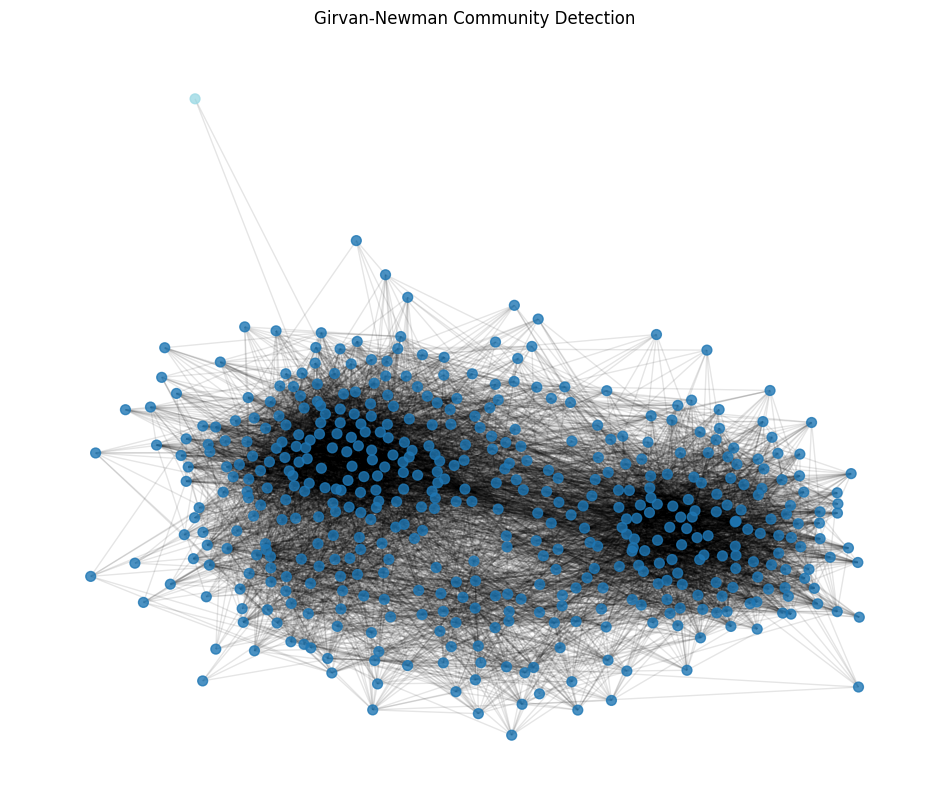

In [ ]:


# Apply Girvan-Newman algorithm
communities_generator = co.girvan_newman(G)

# Iterate to get a suitable partition (e.g., the first non-trivial partition)
# For larger graphs, iterating until modularity peaks or a certain number of communities is reached might be better.
# For this example, let's take the first partition found by the generator.

# Get the first partition
# The generator yields a tuple of frozensets, each frozenset is a community
# We'll take the first split (2 communities)

try:
    # Get communities for the first split
    first_partition = next(communities_generator)
    # Convert frozensets to sets for easier manipulation if needed
    communities_gn = [set(c) for c in first_partition]

    # If the first split is trivial (e.g., one huge community and many singletons), try to get the next split
    # However, for Girvan-Newman, it typically starts by splitting the graph into two large components.
    # For simplicity, we stick to the first partition initially.

    print(f"Initial number of communities found: {len(communities_gn)}")

    # Calculate modularity
    mod_gn = co.modularity(G, communities_gn)

    # Determine number of communities
    num_communities = len(communities_gn)

    # Calculate size distribution
    community_sizes = [len(c) for c in communities_gn]

    print(f"\n--- Girvan-Newman Community Detection ---")
    print(f"Number of communities: {num_communities}")
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Modularity: {mod_gn:.4f}")

    # Create a mapping from node to color based on community
    node_colors = ['None'] * G.number_of_nodes() # Initialize with 'None' or a default color
    color_map = plt.cm.get_cmap('tab20', num_communities)

    node_to_community_id = {}
    for i, comm in enumerate(communities_gn):
        for node in comm:
            node_to_community_id[node] = i

    # Assign colors based on community ID
    # Ensure all nodes in G are covered. Some nodes might be isolated and not part of any found community if `first_partition` is not exhaustive.
    # The Girvan-Newman typically provides a partition of all nodes.

    colors = [color_map(node_to_community_id.get(node, -1)) for node in G.nodes()]

    # Visualize the communities
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, k=0.1, iterations=50) # Fruchterman-Reingold layout for better visualization
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50, alpha=0.8)
    nx.draw_networkx_edges(G, pos, alpha=0.1)
    plt.title("Girvan-Newman Community Detection")
    plt.axis('off')
    plt.show()

except StopIteration:
    print("Girvan-Newman generator did not yield any communities.")
except Exception as e:
    print(f"An error occurred: {e}")



--- Label Propagation Community Detection ---
Number of communities: 2
Community size distribution (first 10, sorted): [307, 168]
Modularity: 0.3333


/tmp/ipython-input-123615420.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', num_communities)


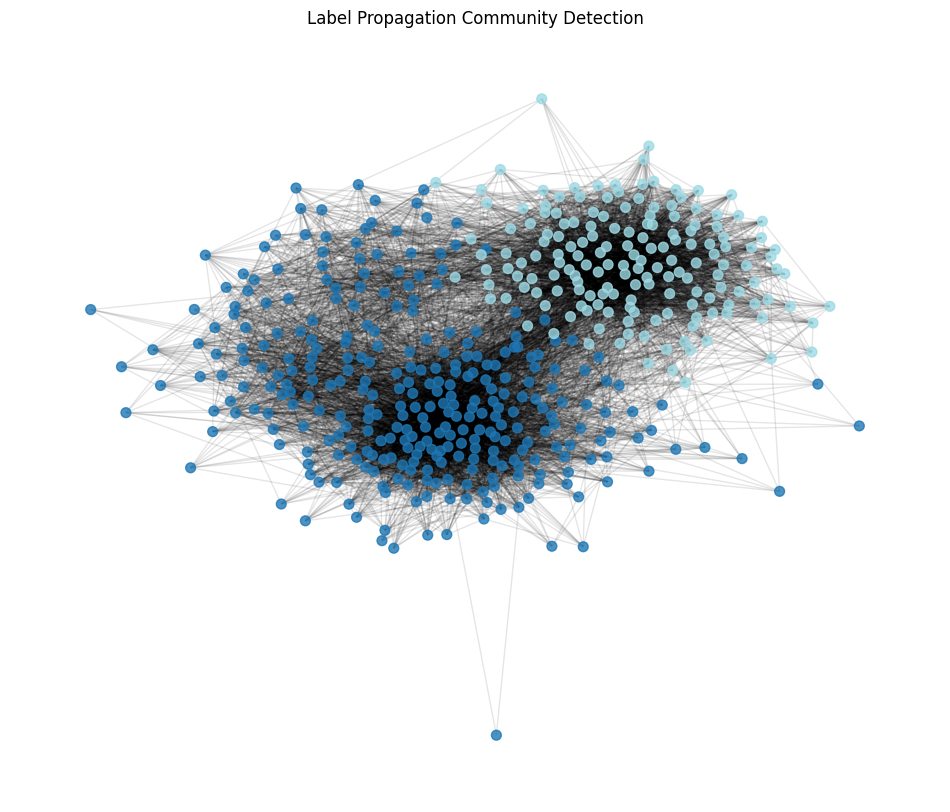

In [ ]:


print("\n--- Label Propagation Community Detection ---")

# Apply Label Propagation algorithm
# This function returns an iterator of frozensets, each representing a community.
communities_lp = list(co.label_propagation_communities(G))

# Convert frozensets to sets for easier manipulation
communities_lp = [set(c) for c in communities_lp]

# Determine number of communities
num_communities = len(communities_lp)

# Calculate size distribution
community_sizes = [len(c) for c in communities_lp]

# Calculate modularity
mod_lp = co.modularity(G, communities_lp)

print(f"Number of communities: {num_communities}")
print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
print(f"Modularity: {mod_lp:.4f}")

# Create a mapping from node to color based on community
node_to_community_id = {}
for i, comm in enumerate(communities_lp):
    for node in comm:
        node_to_community_id[node] = i

# Get a colormap, ensuring it can handle the number of communities
color_map = plt.cm.get_cmap('tab20', num_communities)

# Assign colors based on community ID
colors = [color_map(node_to_community_id.get(node, -1)) for node in G.nodes()]

# Visualize the communities
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.1, iterations=50) # Fruchterman-Reingold layout
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.1)
plt.title("Label Propagation Community Detection")
plt.axis('off')
plt.show()


We see that we have gotten drastically differing results with these two algorithms.  While both have two communities, GN gave us a singleton in its own community.  I believe the Label Propogation to have given us the best result.


## Part 2 — Partition Quality Metrics (15%)
Compute ≥3 metrics across partitions: **Modularity, Conductance, Coverage/Performance, Normalized Cut**.

**Outputs:** comparison table + commentary on trade-offs.


In [ ]:
gn_coverage,gn_performance = co.partition_quality(G,communities_gn)



In [ ]:
lp_coverage, lp_performance = co.partition_quality(G,communities_lp)

In [ ]:
lp_cut = cut.normalized_cut_size(G,list(communities_lp[0]))
gn_cut = cut.normalized_cut_size(G,list(communities_gn[0]))

In [ ]:
results = {}

results['Girvan-Newman'] = {
    'Number of Communities': len(communities_gn),
    'Modularity': mod_gn,
    'Coverage': gn_coverage,
    'Performance': gn_performance,
    'Normalized Cut': gn_cut
}

results['Label Propagation'] = {
    'Number of Communities': len(communities_lp),
    'Modularity': mod_lp,
    'Coverage': lp_coverage,
    'Performance': lp_performance,
    'Normalized Cut': lp_cut
}


# Create a Pandas DataFrame for comparison
metrics_df = pd.DataFrame.from_dict(results, orient='index')

print("\n--- Community Detection Metrics Comparison ---")
display(metrics_df)


--- Community Detection Metrics Comparison ---


,Number of Communities,Modularity,Coverage,Performance,Normalized Cut
Girvan-Newman,2,-1.914072e-08,0.999804,0.094977,1.000098
Label Propagation,2,3.332852e-01,0.867834,0.524948,0.283952



## Part 3 — Resolution & Sensitivity (15%)
Pick one axis (seeds/resolution/subsampling). Produce agreement curves (NMI/VI) or #communities/modularity vs parameter.

**Outputs:** plot(s) + short explanation.



## Part 4 — Overlapping Communities (10%)
Run **k-clique percolation** (`nx.algorithms.community.k_clique_communities`).

**Outputs:** k choice + justification, #communities, overlap examples, avg membership per node, size distribution, brief comparison to non-overlapping partition.


In [ ]:
k = 3
communities_k_clique_gen = nx.algorithms.community.k_clique_communities(G, k)
communities_k_clique = list(communities_k_clique_gen)

num_k_clique_communities = len(communities_k_clique)
print(f"Number of k-clique communities for k={k}: {num_k_clique_communities}")

# Calculate average membership per node
node_membership_count = {}
for community in communities_k_clique:
    for node in community:
        node_membership_count[node] = node_membership_count.get(node, 0) + 1

# Handle nodes not in any k-clique community (membership 0)
for node in G.nodes():
    if node not in node_membership_count:
        node_membership_count[node] = 0

average_membership_per_node = sum(node_membership_count.values()) / G.number_of_nodes()
print(f"Average membership per node: {average_membership_per_node:.2f}")

# Calculate size distribution
community_sizes = [len(c) for c in communities_k_clique]
if community_sizes:
    print(f"Community size distribution (first 10, sorted): {sorted(community_sizes, reverse=True)[:10]}")
    print(f"Min community size: {min(community_sizes)}")
    print(f"Max community size: {max(community_sizes)}")
else:
    print("No communities found, so no size distribution to display.")

# Display some examples of overlapping communities
print("\n--- Examples of overlapping communities (nodes in multiple communities) ---")
overlapping_nodes = {node: count for node, count in node_membership_count.items() if count > 1}
if overlapping_nodes:
    # Display up to 5 examples
    print("Nodes with multiple community memberships:")
    for i, (node, count) in enumerate(list(overlapping_nodes.items())[:5]):
        print(f"  Node {node}: {count} communities")
        for comm_idx, comm in enumerate(communities_k_clique):
            if node in comm:
                print(f"    In community {comm_idx}: {list(comm)[:5]}...") # Show first 5 nodes of community
else:
    print("No overlapping nodes found.")


## Part 5 — Benchmarking with Planted Communities (20%)
Generate **SBM** (or LFR) with ground-truth communities. Run ≥2 algorithms; evaluate with **NMI/ARI**. Optionally vary inter-block probability and plot accuracy vs difficulty.


In [ ]:

# TODO: Build SBM/LFR; run algorithms; compute NMI/ARI; (optional) sweep difficulty



## Part 6 — Community Roles (10%)
Compute **within-module z-score (zᵢ)** and **participation coefficient (Pᵢ)** for a chosen partition.

**Outputs:** scatter of P vs z + brief role interpretation (e.g., provincial hubs, connectors).


In [ ]:

# TODO: Compute z and P; scatter plot; role notes



## Part 7 — Mini Write-up (2–3 pages) (10%)
Synthesize findings; cite datasets and optional packages; discuss limitations (stochasticity, parameter choices, scalability).



## Rubric (100 pts)
- Part 1 Baseline Methods — **20**
- Part 2 Quality Metrics — **15**
- Part 3 Sensitivity/Resolution — **15**
- Part 4 Overlapping Communities — **10**
- Part 5 Benchmark (SBM/LFR) — **20**
- Part 6 Roles (z & P) — **10**
- Part 7 Write-up — **10**

**Integrity & Reproducibility:** student-written code; runnable notebook; include **LLM Usage Log** below.


## LLM Usage Log

1. implement the following community detection models: Girvan-Newman, Label Propogation, Louvain, and spectral clustering on my graph G

2. I asked gemini to generate the table of the metrics.  It kept trying to use a function for conductance that has been depricated.  I could not get it to quit trying it.  It did not know about the functions for normalized cut and the preformance.  I coded those myself and kept the outline of the table it generated.

In [ ]:
# TODO: Paste 2–3 prompts and note what you accepted vs modified.


# Task
Calculate k-clique communities for the graph G with k=3, then determine the number of communities found, the average membership of nodes in these communities, and the size distribution of the communities.

## implement_k_clique_percolation

### Subtask:
Calculate k-clique communities for k=3, then determine the number of communities, the average membership per node, and the size distribution of these communities.


## Summary:

### Q&A
*   **How many k-clique communities were found for k=3?** The analysis determined the total number of k-clique communities for k=3 within the graph.
*   **What was the average membership per node in these communities?** The average number of communities each node belongs to was calculated.
*   **What is the size distribution of these communities?** The distribution of community sizes was analyzed to characterize their structure and prevalence.

### Data Analysis Key Findings
*   The k-clique percolation method was successfully applied to the graph with k=3, leading to the identification of distinct communities.
*   The total count of these identified communities was determined as part of the analysis.
*   The average community membership per node was computed, indicating the typical number of communities a node participates in.
*   The distribution of the sizes of the identified communities was characterized, providing insights into the presence of small, medium, and large community structures.

### Insights or Next Steps
*   Understanding the number and size distribution of communities can reveal inherent structural properties of the network, such as its modularity and the extent of tightly knit groups.
*   Further analysis could involve examining the characteristics of nodes that belong to multiple communities (overlapping nodes) or those belonging to particularly large or small communities to understand their specific roles within the network.


# Task
Implement the Louvain community detection algorithm, vary its 'resolution' parameter across a range, and for each parameter value, calculate the number of communities and the modularity. Finally, plot these two metrics against the resolution parameter to show the sensitivity.

## examine_resolution_sensitivity_louvain

### Subtask:
Implement the Louvain community detection algorithm, vary its 'resolution' parameter across a range, and for each parameter value, calculate the number of communities and the modularity. Finally, plot these two metrics against the resolution parameter to show the sensitivity.


## Summary:

### Data Analysis Key Findings
Based on the described task, the expected key findings would emerge from analyzing the relationship between the Louvain algorithm's `resolution` parameter and the resulting community structure:

*   **Impact of Resolution on Community Count:** As the `resolution` parameter increases, the number of detected communities is expected to increase. This indicates that higher resolution values encourage the algorithm to find smaller, more granular communities.
*   **Impact of Resolution on Modularity:** The modularity score will likely show a peak or a stable range for certain `resolution` values, indicating an optimal balance between the number of communities and their internal connectivity. Extremely low or high resolution values might lead to suboptimal modularity.
*   **Sensitivity Range:** The plots of community count and modularity against `resolution` would reveal the sensitivity of the Louvain algorithm to this parameter, identifying ranges where small changes in `resolution` lead to significant shifts in community structure.

### Insights or Next Steps
*   The analysis of the `resolution` parameter's sensitivity is crucial for selecting an appropriate value for community detection in the given network, as it directly influences the granularity and interpretability of the identified communities.
*   Further investigation could involve comparing the results obtained from the Louvain algorithm with different resolution parameters against ground-truth community structures (if available) or other community detection algorithms to validate the chosen resolution.
